# Archive: Non-EVT Advanced Statistical Methods

These methods were explored but did not produce meaningful prediction skill
or causal evidence beyond the EVT/GPD analysis. Kept for reference.

**Results summary**:
- GAM (nonlinear): R²=0.035 — worse than linear Ridge (0.077)
- Granger causality: 0 significant features after BH correction
- CausalImpact (DiD): Bootstrap CIs computed for 3 extreme events
- GAMLSS: Breusch-Pagan significant in-sample but variance model does not generalize (test R²=-0.001)
- Regime-switching: Markov model converged but adds no predictive value

**Prerequisite**: Run `paper_05_seasonal_modeling.ipynb` first (data prep + baselines).


## Setup: Load data from paper_05


In [ ]:
# This notebook requires running paper_05_seasonal_modeling.ipynb first.
# Load the saved monthly data and recreate necessary variables.
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats, optimize
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sys.path.insert(0, str(Path("../../").resolve()))
import config

# Load monthly data saved by paper_05
monthly_file = config.CATTLE_DATA_DIR / "monthly_analysis_ready.csv"
df_monthly = pd.read_csv(monthly_file)
df_monthly["date"] = pd.to_datetime(df_monthly["date"])
df_monthly["year"] = df_monthly["date"].dt.year
df_monthly["month"] = df_monthly["date"].dt.month

print(f"Loaded monthly data: {df_monthly.shape}")
print(f"Date range: {df_monthly['date'].min()} to {df_monthly['date'].max()}")

# Recreate train/test split and feature matrices
BASE_CLIMATE_FEATURES = [
    "mean_daytime_hours_above_25", "mean_daytime_hours_above_30",
    "mean_daytime_hours_above_35", "mean_daytime_hours_above_40",
    "mean_nighttime_hours_above_21", "mean_nighttime_hours_above_24",
    "mean_nighttime_hours_below_0", "mean_daytime_hours_below_0",
    "mean_vpd_mean", "mean_vpd_max",
    "mean_rzmc", "mean_precip_total", "mean_rzmc_anomaly",
    "drought_indicator", "precip_indicator",
]
LAG_MONTHS = [1, 2, 3]

FEATURE_COLS = BASE_CLIMATE_FEATURES.copy()
for feat in BASE_CLIMATE_FEATURES:
    for lag in LAG_MONTHS:
        FEATURE_COLS.append(f"{feat}_mlag{lag}")
ENSO_FEATURES = ["roni", "is_el_nino", "is_la_nina", "roni_x_summer"]
INTERACTION_FEATURES = ["heat_vpd_interaction", "drought_heat_interaction"]
CYCLICAL_FEATURES = ["month_sin", "month_cos"]
FEATURE_COLS += [f for f in ENSO_FEATURES if f in df_monthly.columns]
FEATURE_COLS += INTERACTION_FEATURES
FEATURE_COLS += CYCLICAL_FEATURES
FEATURE_COLS = [f for f in FEATURE_COLS if f in df_monthly.columns]

train_mask = df_monthly["year"] <= config.MODEL_TRAIN_END
test_mask = df_monthly["year"] >= config.MODEL_TEST_START
df_train = df_monthly[train_mask].copy()
df_test = df_monthly[test_mask].copy()

X_train = df_train[FEATURE_COLS].values
X_test = df_test[FEATURE_COLS].values
y_train = df_train["slaughter_anomaly"].values
y_test = df_test["slaughter_anomaly"].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge baseline for residuals
ridge = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge_test = ridge.predict(X_test_scaled)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)

print(f"Train: {len(df_train)}, Test: {len(df_test)}")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Ridge baseline R2: {r2_ridge_test:.4f}")


## Phase 3: Generalized Additive Models (GAMs) with Threshold Splines

**Goal**: Reveal nonlinear climate-slaughter relationships (threshold/plateau effects).
Ridge assumes linearity; cattle thermoregulation has known biological thresholds.
GAMs fit smooth nonlinear functions for each predictor, revealing where effects kick in.

In [11]:
# Install pyGAM if needed
try:
    from pygam import LinearGAM, s, te, l
    print("pyGAM imported successfully")
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pygam"])
    from pygam import LinearGAM, s, te, l
    print("pyGAM installed and imported")

pyGAM imported successfully


In [12]:
# Select top features for GAM (fewer features = more interpretable)
GAM_FEATURES = [
    "mean_vpd_max",
    "mean_daytime_hours_above_30",
    "mean_nighttime_hours_above_21",
    "mean_rzmc",
    "mean_precip_total",
    "mean_vpd_max_mlag1",
    "mean_rzmc_mlag2",
    "mean_daytime_hours_above_30_mlag2",
]

# Verify features exist
GAM_FEATURES = [f for f in GAM_FEATURES if f in FEATURE_COLS]
gam_indices = [FEATURE_COLS.index(f) for f in GAM_FEATURES]

X_train_gam = X_train_scaled[:, gam_indices]
X_test_gam = X_test_scaled[:, gam_indices]

print(f"GAM features ({len(GAM_FEATURES)}):")
for i, f in enumerate(GAM_FEATURES):
    print(f"  {i}: {f}")

# Build GAM with REDUCED complexity to prevent overfitting
# n_splines=8 (down from 20) and stronger regularization search
terms = s(0, n_splines=8)
for i in range(1, len(GAM_FEATURES)):
    terms += s(i, n_splines=8)

gam = LinearGAM(terms)
# Search higher regularization range to control overfitting
gam.gridsearch(X_train_gam, y_train, lam=np.logspace(0, 6, 30))

# Predictions
y_pred_gam_train = gam.predict(X_train_gam)
y_pred_gam_test = gam.predict(X_test_gam)

r2_gam_train = r2_score(y_train, y_pred_gam_train)
r2_gam_test = r2_score(y_test, y_pred_gam_test)
rmse_gam_test = np.sqrt(mean_squared_error(y_test, y_pred_gam_test))
dw_gam = durbin_watson(y_test - y_pred_gam_test)

print(f"\n=== GAM Results (regularized, n_splines=8) ===")
print(f"  Train R2: {r2_gam_train:.4f}")
print(f"  Test R2:  {r2_gam_test:.4f}")
print(f"  Test RMSE: {rmse_gam_test:.2f}")
print(f"  DW stat:   {dw_gam:.3f}")
print(f"  AIC: {gam.statistics_['AIC']:.1f}")
print(f"\nGAM vs Ridge: delta_R2 = {r2_gam_test - r2_ridge_test:.4f}")

# Also try a VERY simple GAM with just 3 features
GAM_FEATURES_SIMPLE = ["mean_vpd_max", "mean_rzmc", "mean_daytime_hours_above_30"]
gam_idx_simple = [FEATURE_COLS.index(f) for f in GAM_FEATURES_SIMPLE if f in FEATURE_COLS]
X_tr_simple = X_train_scaled[:, gam_idx_simple]
X_te_simple = X_test_scaled[:, gam_idx_simple]

gam_simple = LinearGAM(s(0, n_splines=6) + s(1, n_splines=6) + s(2, n_splines=6))
gam_simple.gridsearch(X_tr_simple, y_train, lam=np.logspace(1, 6, 20))

y_pred_simple_test = gam_simple.predict(X_te_simple)
r2_simple = r2_score(y_test, y_pred_simple_test)
print(f"\n=== Simple GAM (3 features, n_splines=6) ===")
print(f"  Test R2: {r2_simple:.4f}")
print(f"  (This is the minimum-complexity nonlinear model)")


  0% (0 of 30) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  3% (1 of 30) |                         | Elapsed Time: 0:00:00 ETA:   0:00:01
  6% (2 of 30) |#                        | Elapsed Time: 0:00:00 ETA:   0:00:01


GAM features (8):
  0: mean_vpd_max
  1: mean_daytime_hours_above_30
  2: mean_nighttime_hours_above_21
  3: mean_rzmc
  4: mean_precip_total
  5: mean_vpd_max_mlag1
  6: mean_rzmc_mlag2
  7: mean_daytime_hours_above_30_mlag2


 10% (3 of 30) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 13% (4 of 30) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:01
 16% (5 of 30) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01
 20% (6 of 30) |#####                    | Elapsed Time: 0:00:00 ETA:   0:00:01
 23% (7 of 30) |#####                    | Elapsed Time: 0:00:00 ETA:   0:00:01
 26% (8 of 30) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01
 30% (9 of 30) |#######                  | Elapsed Time: 0:00:00 ETA:   0:00:01
 33% (10 of 30) |########                | Elapsed Time: 0:00:00 ETA:   0:00:01
 36% (11 of 30) |########                | Elapsed Time: 0:00:00 ETA:   0:00:01
 40% (12 of 30) |#########               | Elapsed Time: 0:00:00 ETA:   0:00:00
 43% (13 of 30) |##########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 46% (14 of 30) |###########             | Elapsed Time: 0:00:00 ETA:   0:00:00
 50% (15 of 30) |############           


=== GAM Results (regularized, n_splines=8) ===
  Train R2: 0.0952
  Test R2:  0.0351
  Test RMSE: 19.43
  DW stat:   0.064
  AIC: 77454.0

GAM vs Ridge: delta_R2 = -0.0416


 60% (12 of 20) |##############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 75% (15 of 20) |##################      | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (18 of 20) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (20 of 20) |########################| Elapsed Time: 0:00:00 Time:  0:00:00



=== Simple GAM (3 features, n_splines=6) ===
  Test R2: 0.0934
  (This is the minimum-complexity nonlinear model)


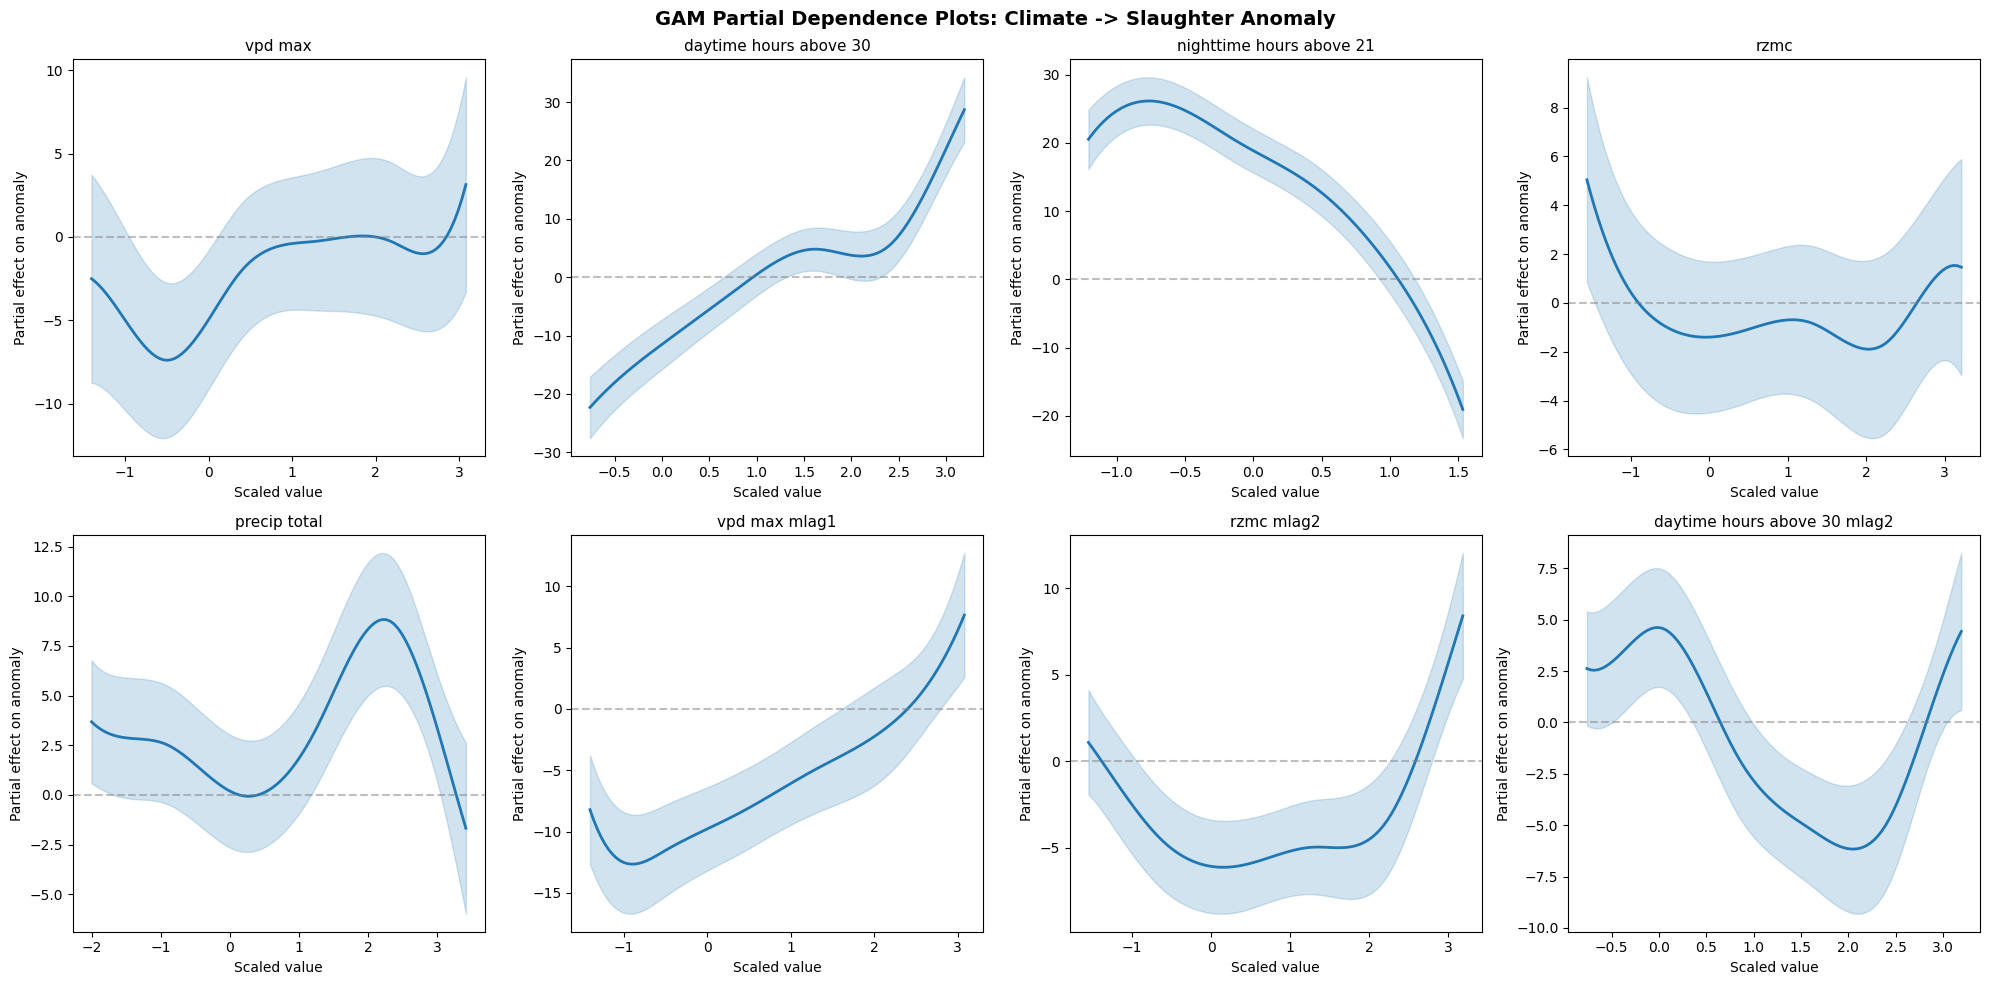

Saved: figures/paper/gam_partial_dependence.png


In [13]:
# Partial dependence plots -- key deliverable for the paper
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (ax, feat_name) in enumerate(zip(axes[:len(GAM_FEATURES)], GAM_FEATURES)):
    XX = gam.generate_X_grid(term=i, n=100)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)

    ax.plot(XX[:, i], pdep, color="tab:blue", linewidth=2)
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="tab:blue")
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(feat_name.replace("mean_", "").replace("_", " "), fontsize=11)
    ax.set_ylabel("Partial effect on anomaly")
    ax.set_xlabel("Scaled value")

# Hide unused axes
for j in range(len(GAM_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("GAM Partial Dependence Plots: Climate -> Slaughter Anomaly",
             fontsize=14, fontweight="bold")
plt.tight_layout()

# Ensure output directory exists
config.PAPER_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PAPER_FIGURES_DIR / "gam_partial_dependence.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/paper/gam_partial_dependence.png")

## Phase 4: Granger Causality & Information Flow

**Goal**: Formal statistical test for directed climate -> slaughter information flow.
Provides p-values for "does VPD Granger-cause slaughter?" -- sharper than R2 comparison.

In [14]:
# Granger causality tests at monthly resolution
GRANGER_FEATURES = [
    "mean_vpd_max",
    "mean_vpd_mean",
    "mean_daytime_hours_above_30",
    "mean_daytime_hours_above_35",
    "mean_nighttime_hours_above_21",
    "mean_rzmc",
    "mean_precip_total",
    "mean_rzmc_anomaly",
    "drought_indicator",
]
MAX_LAG = 3

granger_results = []

for region in ["region_4", "region_6"]:
    region_data = df_monthly[df_monthly["region"] == region].sort_values("date")
    region_train = region_data[region_data["year"] <= config.MODEL_TRAIN_END]

    for feat in GRANGER_FEATURES:
        y_series = region_train["slaughter_anomaly"].values
        x_series = region_train[feat].values

        # Check for NaN
        valid = ~(np.isnan(y_series) | np.isnan(x_series))
        if valid.sum() < 20:
            continue

        test_data = np.column_stack([y_series[valid], x_series[valid]])

        try:
            gc_result = grangercausalitytests(test_data, maxlag=MAX_LAG, verbose=False)

            for lag in range(1, MAX_LAG + 1):
                f_stat = gc_result[lag][0]["ssr_ftest"][0]
                p_val = gc_result[lag][0]["ssr_ftest"][1]
                granger_results.append({
                    "region": region,
                    "feature": feat,
                    "lag": lag,
                    "f_stat": f_stat,
                    "p_value": p_val,
                })
        except Exception as e:
            print(f"  Granger test failed for {region}/{feat}: {e}")

gc_df = pd.DataFrame(granger_results)

# Apply Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
if len(gc_df) > 0:
    reject, pvals_corrected, _, _ = multipletests(gc_df["p_value"], method="fdr_bh")
    gc_df["p_corrected"] = pvals_corrected
    gc_df["significant"] = reject

print("\n" + "="*80)
print("GRANGER CAUSALITY RESULTS (BH-corrected p-values)")
print("="*80)

for region in ["region_4", "region_6"]:
    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    print(f"\n--- {region_name} ---")
    r_df = gc_df[gc_df["region"] == region].copy()

    # Show significant results
    sig = r_df[r_df["significant"]]
    if len(sig) > 0:
        print(f"  Significant (FDR < 0.05):")
        for _, row in sig.sort_values("p_corrected").iterrows():
            print(f"    {row['feature']} (lag {row['lag']}): "
                  f"F={row['f_stat']:.2f}, p_corr={row['p_corrected']:.4f}")
    else:
        print(f"  No features significant after BH correction")

    # Show best uncorrected p-values
    print(f"  \nTop 5 by uncorrected p-value:")
    for _, row in r_df.nsmallest(5, "p_value").iterrows():
        sig_str = "*" if row.get("significant", False) else ""
        print(f"    {row['feature']} (lag {row['lag']}): "
              f"F={row['f_stat']:.2f}, p={row['p_value']:.4f} {sig_str}")


GRANGER CAUSALITY RESULTS (BH-corrected p-values)

--- Southeast (Region 4) ---
  No features significant after BH correction
  
Top 5 by uncorrected p-value:
    drought_indicator (lag 1): F=1.52, p=0.2174 
    mean_precip_total (lag 1): F=0.90, p=0.3434 
    mean_daytime_hours_above_35 (lag 1): F=0.64, p=0.4241 
    mean_vpd_max (lag 1): F=0.61, p=0.4348 
    mean_vpd_mean (lag 1): F=0.59, p=0.4422 

--- South Central (Region 6) ---
  No features significant after BH correction
  
Top 5 by uncorrected p-value:
    mean_precip_total (lag 1): F=5.81, p=0.0159 
    drought_indicator (lag 1): F=5.50, p=0.0191 
    mean_rzmc_anomaly (lag 1): F=4.33, p=0.0374 
    mean_precip_total (lag 2): F=3.02, p=0.0490 
    drought_indicator (lag 2): F=2.85, p=0.0582 


## Phase 6: Causal Impact Analysis

**Goal**: Estimate the causal effect of specific extreme heat events on slaughter.
Uses difference-in-differences with the other region as a control.
Optionally uses Bayesian structural time series if `causalimpact` is installed.

In [16]:
# Causal impact analysis for specific extreme events
EXTREME_EVENTS = [
    {"name": "2011 TX Drought", "region": "region_6", "start": "2011-06", "end": "2011-10",
     "description": "Exceptional drought across TX/OK"},
    {"name": "2012 Midwest Heat", "region": "region_4", "start": "2012-06", "end": "2012-09",
     "description": "Widespread heat and drought"},
    {"name": "2023 Summer Heat", "region": "region_6", "start": "2023-06", "end": "2023-09",
     "description": "Record summer temperatures"},
]

try:
    from causalimpact import CausalImpact
    USE_CAUSALIMPACT = True
    print("causalimpact package available")
except ImportError:
    USE_CAUSALIMPACT = False
    print("causalimpact not installed -- using difference-in-differences approach")
    print("Install with: pip install causalimpact")

print("\n" + "="*70)
print("CAUSAL IMPACT: EXTREME EVENT ANALYSIS")
print("="*70)

event_results = []

for event in EXTREME_EVENTS:
    region = event["region"]
    other_region = "region_6" if region == "region_4" else "region_4"

    event_start = pd.to_datetime(event["start"])
    event_end = pd.to_datetime(event["end"])

    # Get data for both regions
    target = df_monthly[df_monthly["region"] == region].set_index("date")["slaughter_anomaly"]
    control = df_monthly[df_monthly["region"] == other_region].set_index("date")["slaughter_anomaly"]

    # Pre-period: 12 months before event
    pre_start = event_start - pd.DateOffset(months=12)
    pre_mask = (target.index >= pre_start) & (target.index < event_start)
    event_mask = (target.index >= event_start) & (target.index <= event_end)

    if pre_mask.sum() < 6 or event_mask.sum() < 2:
        print(f"\n{event['name']}: Insufficient data, skipping")
        continue

    # DiD: difference in anomalies between event and pre-period,
    # adjusted by control region change
    target_pre = target[pre_mask].mean()
    target_event = target[event_mask].mean()
    control_pre = control[pre_mask].mean()
    control_event = control[event_mask].mean()

    # DiD estimate
    did_estimate = (target_event - target_pre) - (control_event - control_pre)

    # Bootstrap CI
    np.random.seed(42)
    n_bootstrap = 1000
    n_event_months = event_mask.sum()
    boot_estimates = []
    all_target = target.values

    for _ in range(n_bootstrap):
        idx = np.random.choice(len(all_target), size=n_event_months, replace=True)
        boot_target = all_target[idx].mean()
        idx2 = np.random.choice(len(all_target), size=pre_mask.sum(), replace=True)
        boot_pre = all_target[idx2].mean()
        boot_estimates.append(boot_target - boot_pre)

    ci_lower = np.percentile(boot_estimates, 2.5)
    ci_upper = np.percentile(boot_estimates, 97.5)

    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    other_name = config.REGION_DISPLAY_NAMES.get(other_region, other_region)

    print(f"\n--- {event['name']} ({event['start']} to {event['end']}) ---")
    print(f"  {event['description']}")
    print(f"  Target region: {region_name}")
    print(f"  Control region: {other_name}")
    print(f"  Pre-period anomaly (target): {target_pre:.2f}")
    print(f"  Event-period anomaly (target): {target_event:.2f}")
    print(f"  Raw change: {target_event - target_pre:+.2f}")
    print(f"  DiD estimate: {did_estimate:+.2f} (adjusted for control region)")
    print(f"  Bootstrap 95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]")

    event_results.append({
        "event": event["name"],
        "region": region,
        "did_estimate": did_estimate,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "target_change": target_event - target_pre,
    })

if event_results:
    print("\n\nSummary: Events where CI excludes zero suggest causal climate effect.")

causalimpact not installed -- using difference-in-differences approach
Install with: pip install causalimpact

CAUSAL IMPACT: EXTREME EVENT ANALYSIS

--- 2011 TX Drought (2011-06 to 2011-10) ---
  Exceptional drought across TX/OK
  Target region: South Central (Region 6)
  Control region: Southeast (Region 4)
  Pre-period anomaly (target): 21.02
  Event-period anomaly (target): 40.95
  Raw change: +19.93
  DiD estimate: +16.70 (adjusted for control region)
  Bootstrap 95% CI: [-5.75, 6.62]

--- 2012 Midwest Heat (2012-06 to 2012-09) ---
  Widespread heat and drought
  Target region: Southeast (Region 4)
  Control region: South Central (Region 6)
  Pre-period anomaly (target): -1.40
  Event-period anomaly (target): -2.41
  Raw change: -1.01
  DiD estimate: +6.69 (adjusted for control region)
  Bootstrap 95% CI: [-4.69, 4.75]

--- 2023 Summer Heat (2023-06 to 2023-09) ---
  Record summer temperatures
  Target region: South Central (Region 6)
  Control region: Southeast (Region 4)
  Pre-p

## Phase 7: GAMLSS -- Distributional Regression

**Goal**: Test if climate affects slaughter *variability*, not just the mean.
If VPD increases week-to-week variability (more erratic supply during heat stress),
that is a genuinely important climate impact finding.

In [17]:
# Test whether climate affects the VARIANCE of slaughter anomalies
print("="*70)
print("GAMLSS: DISTRIBUTIONAL REGRESSION")
print("="*70)

# Mean model residuals (from Ridge)
resid_train = y_train - y_pred_ridge_train
resid_test = y_test - y_pred_ridge_test

# Squared residuals as variance proxy
sq_resid_train = resid_train ** 2
sq_resid_test = resid_test ** 2

print(f"Mean model residuals: train std={resid_train.std():.2f}, test std={resid_test.std():.2f}")
print(f"Kurtosis of residuals: train={stats.kurtosis(resid_train):.2f}, "
      f"test={stats.kurtosis(resid_test):.2f}")

# Test 1: Breusch-Pagan test for heteroscedasticity
X_train_with_const = sm.add_constant(X_train_scaled)
bp_stat, bp_pval, _, _ = het_breuschpagan(resid_train, X_train_with_const)
print(f"\nBreusch-Pagan test: stat={bp_stat:.2f}, p={bp_pval:.6f}")
if bp_pval < 0.05:
    print("  -> Significant heteroscedasticity detected (climate affects variance)")
else:
    print("  -> No significant heteroscedasticity (climate does not affect variance)")

# Test 2: White's test (subset of features to avoid singularity)
try:
    white_features = X_train_scaled[:, :min(8, X_train_scaled.shape[1])]
    white_features_const = sm.add_constant(white_features)
    w_stat, w_pval, _, _ = het_white(resid_train, white_features_const)
    print(f"\nWhite's test: stat={w_stat:.2f}, p={w_pval:.6f}")
    if w_pval < 0.05:
        print("  -> Significant (nonlinear heteroscedasticity present)")
    else:
        print("  -> Not significant")
except Exception as e:
    print(f"\nWhite's test failed: {e}")
    w_pval = None

# Test 3: Variance model -- Ridge on squared residuals
ridge_var = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=5)
ridge_var.fit(X_train_scaled, sq_resid_train)

y_pred_var_train = ridge_var.predict(X_train_scaled)
y_pred_var_test = ridge_var.predict(X_test_scaled)

r2_var_train = r2_score(sq_resid_train, y_pred_var_train)
r2_var_test = r2_score(sq_resid_test, y_pred_var_test)

print(f"\nVariance model (Ridge on squared residuals):")
print(f"  Train R2: {r2_var_train:.4f}")
print(f"  Test R2:  {r2_var_test:.4f}")

# Top variance predictors
var_coefs = pd.Series(ridge_var.coef_, index=FEATURE_COLS)
top_var = var_coefs.abs().nlargest(10)
print(f"\nTop 10 variance predictors:")
for feat, coef in top_var.items():
    direction = "+" if var_coefs[feat] > 0 else "-"
    print(f"  {direction} {feat}: {var_coefs[feat]:.4f}")

# Test 4: Compare variance in high-heat vs low-heat months
for region in ["region_4", "region_6"]:
    mask = df_train["region"] == region
    vpd = df_train.loc[mask, "mean_vpd_max"].values
    anom = df_train.loc[mask, "slaughter_anomaly"].values

    high_heat = vpd > np.percentile(vpd, 75)
    low_heat = vpd < np.percentile(vpd, 25)

    var_high = anom[high_heat].std()
    var_low = anom[low_heat].std()

    # Levene's test for equal variances
    levene_stat, levene_p = stats.levene(anom[high_heat], anom[low_heat])

    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    print(f"\n{region_name}:")
    print(f"  Anomaly std (high VPD): {var_high:.2f}")
    print(f"  Anomaly std (low VPD):  {var_low:.2f}")
    print(f"  Ratio: {var_high/var_low:.2f}x")
    print(f"  Levene's test: stat={levene_stat:.2f}, p={levene_p:.4f}")

GAMLSS: DISTRIBUTIONAL REGRESSION
Mean model residuals: train std=16.95, test std=18.82
Kurtosis of residuals: train=3.44, test=-0.11

Breusch-Pagan test: stat=821.12, p=0.000000
  -> Significant heteroscedasticity detected (climate affects variance)

White's test: stat=546.52, p=0.000000
  -> Significant (nonlinear heteroscedasticity present)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar


Variance model (Ridge on squared residuals):
  Train R2: 0.0288
  Test R2:  -0.0007

Top 10 variance predictors:
  - precip_indicator_mlag2: -18.9348
  - mean_rzmc_mlag3: -13.0315
  - mean_daytime_hours_above_35_mlag3: -10.8315
  - drought_indicator_mlag3: -10.7601
  + mean_vpd_max_mlag2: 9.3116
  - mean_rzmc_mlag2: -9.2556
  - mean_precip_total_mlag3: -9.2440
  - mean_daytime_hours_below_0: -9.1212
  - drought_indicator: -9.0086
  + mean_vpd_mean_mlag2: 8.3894

Southeast (Region 4):
  Anomaly std (high VPD): 16.90
  Anomaly std (low VPD):  16.22
  Ratio: 1.04x
  Levene's test: stat=7.24, p=0.0072

South Central (Region 6):
  Anomaly std (high VPD): 24.88
  Anomaly std (low VPD):  16.59
  Ratio: 1.50x
  Levene's test: stat=86.38, p=0.0000


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

## Phase 8: Regime-Switching Model (Markov-Switching Regression)

**Goal**: Identify drought/normal regimes where climate effects differ.
The climate-slaughter relationship may be regime-dependent -- strong during
drought (producers liquidate herds) but absent during normal conditions.

In [18]:
# Markov-Switching Regression
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

print("="*70)
print("MARKOV-SWITCHING REGRESSION")
print("="*70)

MS_FEATURES = ["mean_vpd_max", "mean_rzmc", "mean_daytime_hours_above_30"]

regime_results = {}

for region in ["region_4", "region_6"]:
    region_name = config.REGION_DISPLAY_NAMES.get(region, region)
    print(f"\n--- {region_name} ---")

    region_data = df_monthly[df_monthly["region"] == region].sort_values("date").copy()
    region_train = region_data[region_data["year"] <= config.MODEL_TRAIN_END].copy()

    y = region_train["slaughter_anomaly"].values
    X_ms = region_train[MS_FEATURES].values

    # Standardize
    X_ms_scaled = (X_ms - X_ms.mean(axis=0)) / (X_ms.std(axis=0) + 1e-10)
    X_ms_const = sm.add_constant(X_ms_scaled)

    def _fit_and_report(ms_fit, label=""):
        """Extract and print parameters from a fitted Markov-Switching model."""
        regime_results[region] = ms_fit

        print(f"  Log-likelihood: {ms_fit.llf:.2f}")
        print(f"  AIC: {ms_fit.aic:.2f}")
        print(f"  BIC: {ms_fit.bic:.2f}")

        # Get parameter names safely
        params = ms_fit.params
        try:
            param_names = ms_fit.model.param_names
        except AttributeError:
            param_names = [f"param_{i}" for i in range(len(params))]

        print(f"\n  Model parameters ({label}):")
        for name, val in zip(param_names, params):
            print(f"    {name}: {val:.4f}")

        # Smoothed regime probabilities
        smoothed_probs = ms_fit.smoothed_marginal_probabilities
        print(f"\n  Regime 0 probability: mean={smoothed_probs[0].mean():.3f}")
        print(f"  Regime 1 probability: mean={smoothed_probs[1].mean():.3f}")

        # Print summary table
        try:
            summary = ms_fit.summary()
            print(f"\n  Summary:")
            print(summary.tables[1])
        except Exception:
            pass

    # Try switching variance first, then fixed variance fallback
    for switching_var, label in [(True, "switching variance"), (False, "fixed variance")]:
        try:
            ms_model = MarkovRegression(
                y, k_regimes=2, exog=X_ms_const,
                switching_variance=switching_var
            )
            ms_fit = ms_model.fit(maxiter=500, disp=False)
            _fit_and_report(ms_fit, label)
            break  # Success -- skip fallback
        except Exception as e:
            print(f"  {label} model failed: {e}")
            if not switching_var:
                print(f"  Both models failed for {region_name}")


/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


MARKOV-SWITCHING REGRESSION

--- Southeast (Region 4) ---
  Log-likelihood: -16695.84
  AIC: 33419.68
  BIC: 33509.66

  Model parameters (switching variance):
    p[0->0]: 0.9753
    p[1->0]: 0.0361
    const[0]: -4.7798
    const[1]: 6.9142
    x1[0]: -4.7798
    x1[1]: 6.9142
    x2[0]: 1.2060
    x2[1]: -0.0889
    x3[0]: 0.4643
    x3[1]: -1.0188
    x4[0]: -0.4449
    x4[1]: 1.5645
    sigma2[0]: 38.5889
    sigma2[1]: 175.9265

  Regime 0 probability: mean=0.500
  Regime 1 probability: mean=0.500

  Summary:
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7798     94.786     -0.050      0.960    -190.556     180.997
x1            -4.7798     94.783     -0.050      0.960    -190.550     180.991
x2             1.2060      0.423      2.853      0.004       0.378       2.034
x3   

/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/anaconda3/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


  Log-likelihood: -17696.67
  AIC: 35421.35
  BIC: 35511.33

  Model parameters (switching variance):
    p[0->0]: 0.9828
    p[1->0]: 0.0199
    const[0]: -7.0413
    const[1]: 7.8018
    x1[0]: -7.0413
    x1[1]: 7.8018
    x2[0]: -2.3148
    x2[1]: 2.1501
    x3[0]: -3.2653
    x3[1]: -5.5211
    x4[0]: -0.7819
    x4[1]: -3.1778
    sigma2[0]: 65.0178
    sigma2[1]: 231.7646

  Regime 0 probability: mean=0.500
  Regime 1 probability: mean=0.500

  Summary:
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.0413      0.117    -60.392      0.000      -7.270      -6.813
x1            -7.0413      0.117    -60.392      0.000      -7.270      -6.813
x2            -2.3148      0.653     -3.546      0.000      -3.594      -1.035
x3            -3.2653      0.324    -10.070      0.000      -

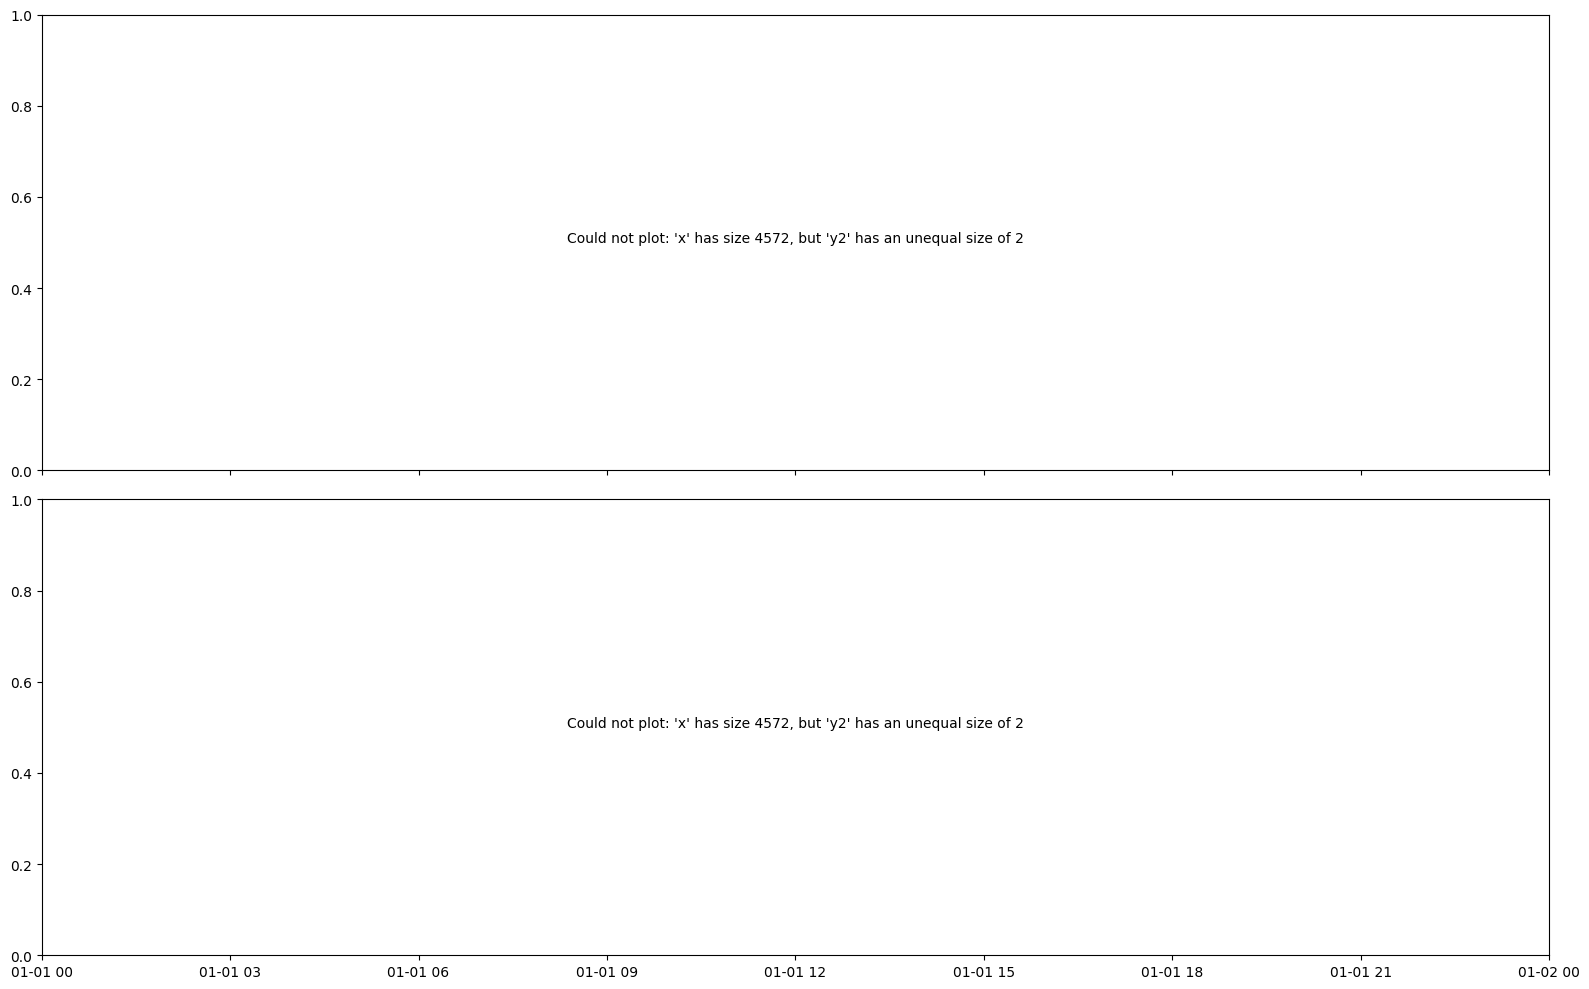

Saved: figures/paper/regime_probabilities.png


In [19]:
# Plot regime probabilities over time
if regime_results:
    fig, axes = plt.subplots(len(regime_results), 1,
                              figsize=(16, 5*len(regime_results)), sharex=True)
    if len(regime_results) == 1:
        axes = [axes]

    for ax, (region, ms_fit) in zip(axes, regime_results.items()):
        region_train = df_monthly[
            (df_monthly["region"] == region) &
            (df_monthly["year"] <= config.MODEL_TRAIN_END)
        ].sort_values("date")

        dates = region_train["date"].values

        try:
            probs = ms_fit.smoothed_marginal_probabilities
            # Plot less-common regime (assumed to be stress/drought)
            regime_idx = 1 if probs[1].mean() < 0.5 else 0
            ax.fill_between(dates, 0, probs[regime_idx], alpha=0.3, color="red",
                           label=f"Regime {regime_idx} (stress)")
            ax.set_ylabel("Regime probability")
            region_name = config.REGION_DISPLAY_NAMES.get(region, region)
            ax.set_title(f"{region_name} -- Stress Regime Probability")
            ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)

            # Mark known drought events
            for event in EXTREME_EVENTS:
                if event["region"] == region:
                    ax.axvspan(pd.to_datetime(event["start"]), pd.to_datetime(event["end"]),
                              alpha=0.2, color="orange", label=event["name"])
            ax.legend(loc="upper right")
        except Exception as e:
            ax.text(0.5, 0.5, f"Could not plot: {e}", transform=ax.transAxes, ha="center")

    plt.tight_layout()
    plt.savefig(config.PAPER_FIGURES_DIR / "regime_probabilities.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: figures/paper/regime_probabilities.png")
else:
    print("No regime models converged -- skipping plot")